In [1]:
from langchain_openai import ChatOpenAI

# Setup API Key
f = open('keys/.openai_api_key.txt')
OPENAI_API_KEY = f.read()

llm = ChatOpenAI(openai_api_key=OPENAI_API_KEY,
                 model="gpt-4o-mini",
                 temperature=0.0)

In [2]:
from langchain_mcp_adapters.client import MultiServerMCPClient

client = MultiServerMCPClient(
    {
        "my_travel_server": {
          "transport": "streamable_http",
          "url": "https://mcp.kiwi.com"
        }
    }
)

flight_toolset = await client.get_tools()

print(f"Loaded {len(flight_toolset)} MCP Tools: {[tool.name for tool in flight_toolset]}")

Loaded 2 MCP Tools: ['search-flight', 'feedback-to-devs']


In [3]:
#! pip install -U ddgs

In [3]:
from langchain.tools import tool
from langchain_community.tools import DuckDuckGoSearchRun
from typing import Dict, Any

search_tool = DuckDuckGoSearchRun()

@tool
def web_search(query: str) -> Dict[str, Any]:
    """ Search the web for information """
    return search_tool.invoke(query)

In [4]:
from langchain_community.utilities import SQLDatabase

db = SQLDatabase.from_uri("sqlite:///database/playlist.db")

db.run("select * from genre")

"[(1, 'Rock'), (2, 'Jazz'), (3, 'Metal'), (4, 'Alternative & Punk'), (5, 'Rock And Roll'), (6, 'Blues'), (7, 'Latin'), (8, 'Reggae'), (9, 'Pop'), (10, 'Soundtrack'), (11, 'Bossa Nova'), (12, 'Easy Listening'), (13, 'Heavy Metal'), (14, 'R&B/Soul'), (15, 'Electronica/Dance'), (16, 'World'), (17, 'Hip Hop/Rap'), (18, 'Science Fiction'), (19, 'TV Shows'), (20, 'Sci Fi & Fantasy'), (21, 'Drama'), (22, 'Comedy'), (23, 'Alternative'), (24, 'Classical'), (25, 'Opera')]"

In [5]:
from langchain_community.agent_toolkits import SQLDatabaseToolkit

db = SQLDatabase.from_uri("sqlite:///database/playlist.db")
toolkit = SQLDatabaseToolkit(db=db, llm=llm)
sql_toolset = toolkit.get_tools()

print(f"Loaded {len(sql_toolset)} MCP Tools: {[tool.name for tool in sql_toolset]}")

Loaded 4 MCP Tools: ['sql_db_query', 'sql_db_schema', 'sql_db_list_tables', 'sql_db_query_checker']


In [6]:
from langchain.agents import AgentState

class WeddingState(AgentState):

    origin: str
    destination: str
    guest_count: int
    genre: str
    wedding_date: str

    flights: str
    venues: str
    playlist: str
    final_plan: str    


In [7]:
from langchain.agents import create_agent

# Travel agent
travel_agent = create_agent(
    model=llm,
    tools=flight_toolset,
    system_prompt="""
You are a travel agent.

Search for flights to the destination wedding location.

Rules:
- Do NOT ask follow-up questions.
- Find economy flights.
- Choose lowest price.
- Prefer shortest duration.

Only search for ONE ticket, ONE way.

You may run multiple searches before selecting the best options.

Return a shortlist of the best flights.
"""
)

In [8]:
# Venue agent
venue_agent = create_agent(
    model=llm,
    tools=[web_search],
    system_prompt="""
You are a wedding venue specialist.

Search for wedding venues matching the requirements.

Criteria:
- Capacity must match the guest count
- Lowest price
- Highest reviews

Return the best venue options.
"""
)

In [9]:
# Playlist agent
playlist_agent = create_agent(
    model=llm,
    tools=sql_toolset,
    system_prompt="""
You are a playlist specialist.

Query the SQL database and create the perfect wedding playlist
based on the requested genre.

Plan music for:
- ceremony
- dinner
- dance party

After selecting songs:
- calculate total playlist duration
- calculate total cost

If queries fail, fix them and retry.
Do NOT return empty results.
"""
)

In [10]:
async def flight_node(state: WeddingState):

    origin = state.get("origin")
    destination = state.get("destination")
    wedding_date = state.get("wedding_date")

    query = f"""
Find economy flights from {origin} to {destination}.

Wedding date: {wedding_date}
"""

    result = await travel_agent.ainvoke({
        "messages": [HumanMessage(content=query)]
    })

    return {"flights": result["messages"][-1].content}

In [11]:
def venue_node(state: WeddingState):

    destination = state.get("destination")
    guest_count = state.get("guest_count")
    wedding_date = state.get("wedding_date")

    query = f"""
Find wedding venues in {destination}.

Requirements:
Capacity: {guest_count}
Date availability: {wedding_date}

Prioritize:
- lowest price
- highest reviews
"""

    result = venue_agent.invoke({
        "messages": [HumanMessage(content=query)]
    })

    return {"venues": result["messages"][-1].content}

In [12]:
def playlist_node(state: WeddingState):

    genre = state.get("genre")

    query = f"""
Create a {genre} wedding playlist.

Plan music for:
- ceremony
- dinner
- dance party
"""

    result = playlist_agent.invoke({
        "messages": [HumanMessage(content=query)]
    })

    return {"playlist": result["messages"][-1].content}

In [13]:
def final_planner_node(state: WeddingState):

    plan = llm.invoke(
        f"""
You are a professional wedding planner.

Create the final wedding plan.

Wedding Date: {state.get('wedding_date')}
Location: {state.get('destination')}
Guests: {state.get('guest_count')}

Flight Options:
{state.get('flights', 'No flight data')}

Venue Options:
{state.get('venues', 'No venue data')}

Playlist:
{state.get('playlist', 'No playlist data')}

Provide:
1. Best flight recommendation
2. Best venue recommendation
3. Wedding day schedule
4. Playlist summary
"""
    )

    return {"final_plan": plan.content}

In [14]:
from langgraph.graph import StateGraph, START, END
workflow = StateGraph(WeddingState)

workflow.add_node("flights", flight_node)
workflow.add_node("venues", venue_node)
workflow.add_node("playlist", playlist_node)
workflow.add_node("final", final_planner_node)

workflow.add_edge(START, "flights")
workflow.add_edge(START, "venues")
workflow.add_edge(START, "playlist")

workflow.add_edge("flights", "final")
workflow.add_edge("venues", "final")
workflow.add_edge("playlist", "final")

workflow.add_edge("final", END)

graph = workflow.compile()



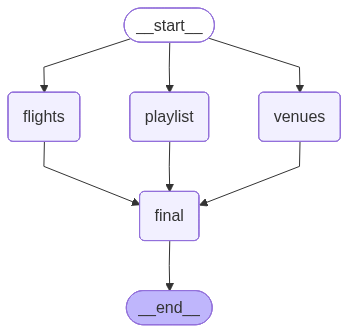

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
from langchain_core.messages import HumanMessage

result = await graph.ainvoke({
    "origin": "New York",
    "destination": "Tuscany",
    "guest_count": 120,
    "genre": "jazz",
    "wedding_date": "June 20 2026"
})


print(result["final_plan"])

### Final Wedding Plan

**Wedding Date:** June 20, 2026  
**Location:** Tuscany  
**Guests:** 120  

---

#### 1. Best Flight Recommendation
**Flight Option:**  
- **Route:** New York JFK → Bucharest OTP → Pisa PSA  
- **Departure:** June 20, 2026, at 13:50  
- **Arrival:** June 21, 2026, at 13:10  
- **Duration:** 17h 20m  
- **Cabin Class:** Economy  
- **Total Price:** $459  
- **Booking Link:** [Book Here](https://on.kiwi.com/nSWHvV)  

**Recommendation:** This option offers the best price and a reasonable duration for your guests traveling from New York to Tuscany.

---

#### 2. Best Venue Recommendation
**Venue:** **Villa Catignano**  
- **Capacity:** Up to 120 guests  
- **Description:** A stunning 17th-century villa located in the heart of the Sienese countryside, featuring formal Italian gardens, frescoed salons, and panoramic terraces overlooking vineyards and olive groves. Ideal for multi-day celebrations with a charming private church.  
- **Reviews:** Highly rated with num